PART-1 DFT(Discrete Fourier Transform)
NumPy Implementation 

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import time

# Set parameters for the signal
N = 2048                 # Number of sample points
T = 1.0                  # Duration of the signal in seconds
f0 = 1                   # Fundamental frequency of the square wave in Hz

# List of harmonic numbers
harmonics = [1, 3, 5, 20, 50]

# Define the square wave function
def square_wave(t):
    return np.sign(np.sin(2.0 * np.pi * f0 * t))


# Fourier series approximation of the square wave
def square_wave_fourier(t, f0, N):
    result = np.zeros_like(t)

    for k in range(N):
        # Square wave contains only odd harmonics
        n = 2 * k + 1

        # Add harmonic
        result += np.sin(2 * np.pi * n * f0 * t) / n

    return (4 / np.pi) * result


# Create the time vector
t = np.linspace(0.0, T, N, endpoint=False)

# Generate original square wave
square = square_wave(t)

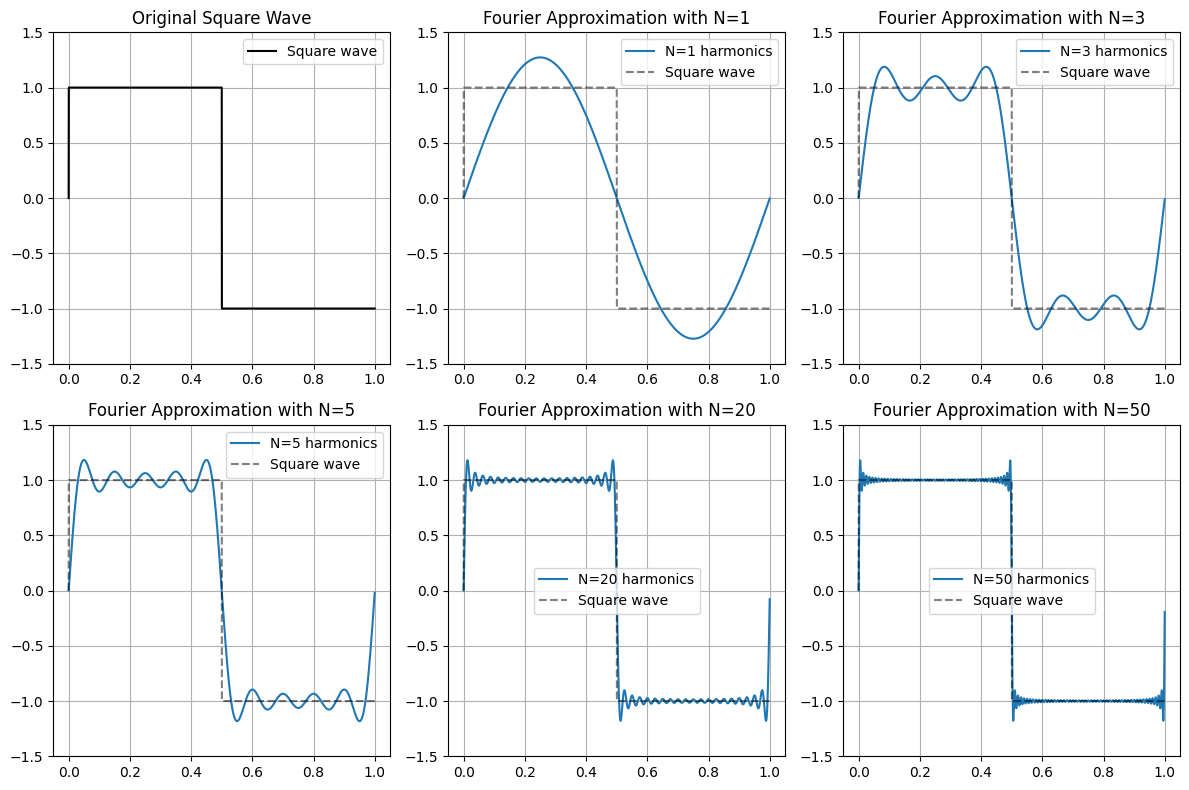

In [12]:
plt.figure(figsize=(12, 8))

# Original square wave
plt.subplot(2, 3, 1)
plt.plot(t, square, 'k', label="Square wave")
plt.title("Original Square Wave")
plt.ylim(-1.5, 1.5)
plt.grid(True)
plt.legend()

# Fourier reconstructions
for i, Nh in enumerate(harmonics, start=2):
    plt.subplot(2, 3, i)

    y = square_wave_fourier(t, f0, Nh)

    plt.plot(t, y, label=f"N={Nh} harmonics")
    plt.plot(t, square, 'k--', alpha=0.5, label="Square wave")

    plt.title(f"Fourier Approximation with N={Nh}")
    plt.ylim(-1.5, 1.5)
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()

Naive Discrete Fourier Transform 

In [13]:
def naive_dft(x):
    """
    Compute the Discrete Fourier Transform (DFT)
    using the direct formula.
    """

    N = len(x)

    # Empty complex array for DFT results
    X = np.zeros(N, dtype=np.complex128)

    # Loop over frequency bins
    for k in range(N):

        # Loop over input samples
        for n in range(N):

            angle = -2j * np.pi * k * n / N

            X[k] += x[n] * np.exp(angle)

    return X

Comparing DFT and FFT Speed

In [14]:
# Construct square wave using 50 harmonics
signal = square_wave_fourier(t, f0, 50)

# -------------------------------
# Naive DFT
# -------------------------------
start_time_naive = time.time()

dft_result = naive_dft(signal)

end_time_naive = time.time()

naive_duration = end_time_naive - start_time_naive


# -------------------------------
# NumPy FFT
# -------------------------------
start_time_fft = time.time()

fft_result = np.fft.fft(signal)

end_time_fft = time.time()

fft_duration = end_time_fft - start_time_fft


# -------------------------------
# Print timings
# -------------------------------
print("--- DFT/FFT Performance Comparison ---")

print(f"Naive DFT Execution Time : {naive_duration:.6f} seconds")
print(f"NumPy FFT Execution Time : {fft_duration:.6f} seconds")

if fft_duration > 0:
    print(
        f"FFT is approximately "
        f"{naive_duration / fft_duration:.2f} times faster."
    )
else:
    print("FFT was too fast to measure.")


# Check whether our DFT agrees with NumPy FFT
print(
    f"Our DFT implementation is close to NumPy's FFT : "
    f"{np.allclose(dft_result, fft_result)}"
)

--- DFT/FFT Performance Comparison ---
Naive DFT Execution Time : 4.894376 seconds
NumPy FFT Execution Time : 0.002162 seconds
FFT is approximately 2263.59 times faster.
Our DFT implementation is close to NumPy's FFT : True


Frequency Plot 

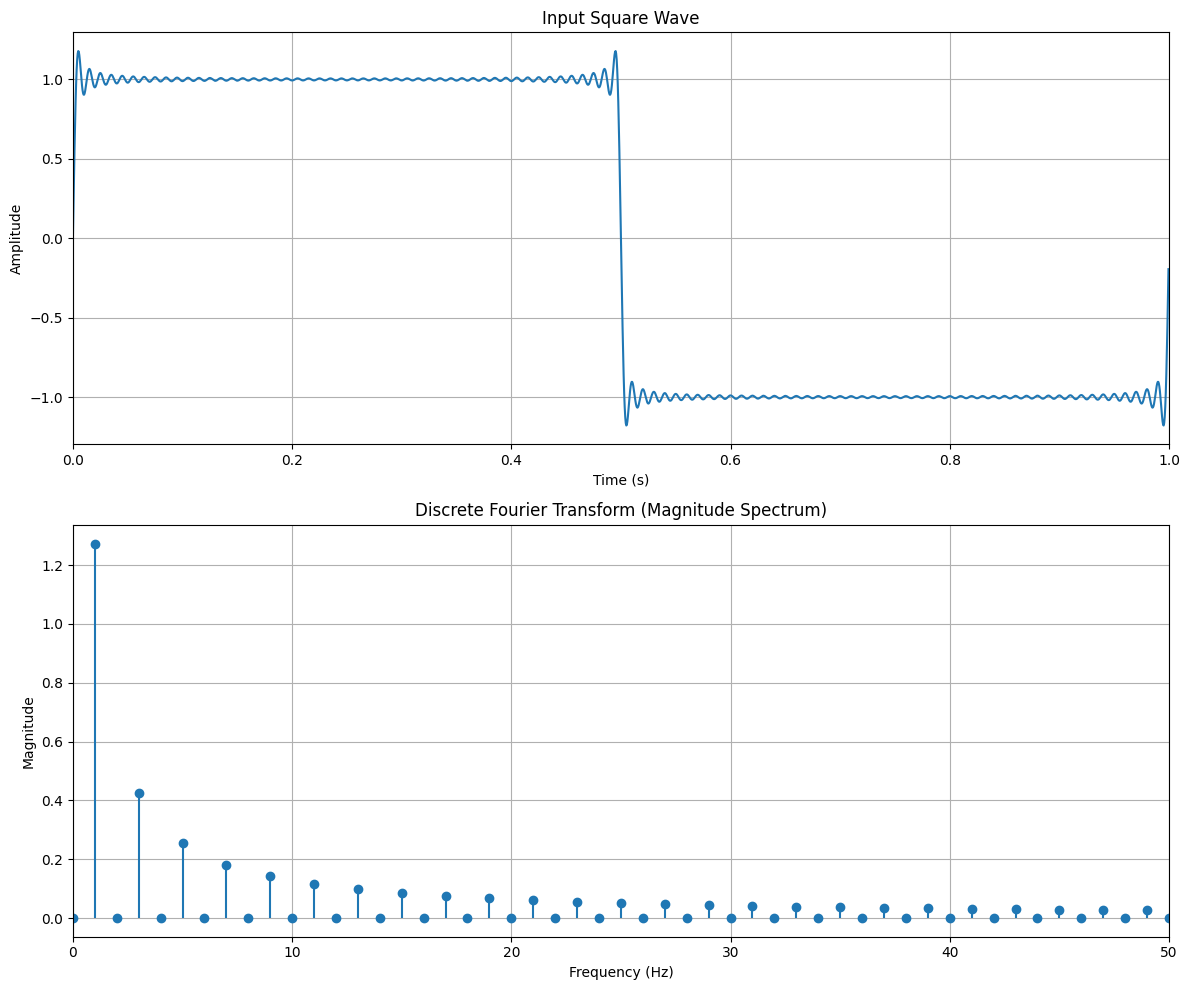

In [15]:
# Frequency axis
xf = np.fft.fftfreq(N, d=T / N)[:N // 2]

# Magnitude of DFT
magnitude = 2.0 / N * np.abs(dft_result[0:N // 2])


# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Time-domain signal
ax1.plot(t, signal)

ax1.set_title("Input Square Wave")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Amplitude")
ax1.set_xlim(0, 1.0)
ax1.grid(True)


# Frequency-domain signal
ax2.stem(xf, magnitude, basefmt=" ")

ax2.set_title("Discrete Fourier Transform (Magnitude Spectrum)")
ax2.set_xlabel("Frequency (Hz)")
ax2.set_ylabel("Magnitude")
ax2.set_xlim(0, 50)
ax2.grid(True)

plt.tight_layout()
plt.show()

PyTorch Implementation

In [16]:
import torch

print("PyTorch version:", torch.__version__)

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU available:", torch.cuda.get_device_name(0))
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Apple GPU (MPS) available")
else:
    device = torch.device("cpu")
    print("No GPU available - using CPU")

print("Using device:", device)

PyTorch version: 2.8.0
Apple GPU (MPS) available
Using device: mps


In [17]:
def torch_square_wave(t, f0):
    return torch.sign(torch.sin(2.0 * torch.pi * f0 * t))

# Create PyTorch time vector
t_torch = torch.linspace(
    0.0,
    T,
    N,
    device=device
)

# Generate square wave
square_torch = torch_square_wave(t_torch, f0)

print(square_torch.shape)
print(square_torch.device)

torch.Size([2048])
mps:0


In [18]:
def torch_square_wave_fourier(t, f0, num_harmonics):

    result = torch.zeros_like(t)

    for k in range(num_harmonics):

        # Odd harmonic
        n = 2 * k + 1

        result += torch.sin(
            2 * torch.pi * n * f0 * t
        ) / n

    return (4 / torch.pi) * result

signal_torch = torch_square_wave_fourier(
    t_torch,
    f0,
    50
)

print(signal_torch.shape)


torch.Size([2048])


PyTorch Naive DFT

In [19]:
def torch_naive_dft(x):

    N = x.shape[0]

    X = torch.zeros(
        N,
        dtype=torch.complex64,
        device=x.device
    )

    for k in range(N):

        for n in range(N):

            angle = -2j * torch.pi * k * n / N

            X[k] += x[n] * torch.exp(
                torch.tensor(
                    angle,
                    dtype=torch.complex64,
                    device=x.device
                )
            )

    return X

N_test = 128

t_test = torch.linspace(
    0.0,
    T,
    N_test,
    device=device
)

signal_test = torch_square_wave_fourier(
    t_test,
    f0,
    50
)


In [20]:
start = time.time()

torch_dft_test = torch_naive_dft(signal_test)

end = time.time()

print("PyTorch DFT time:", end - start)

PyTorch DFT time: 5.31973671913147


In [24]:
sizes = [128, 256, 512, 1024]

print("N\tCPU Time\tMPS Time")
print("-" * 40)

for N_size in sizes:

    # ---------------- CPU ----------------
    t_cpu = torch.linspace(0.0, T, N_size)
    signal_cpu = torch_square_wave_fourier(t_cpu, f0, 50)

    start = time.time()
    result_cpu = torch_vectorised_dft(signal_cpu)
    cpu_time = time.time() - start


    # ---------------- MPS ----------------
    t_mps = torch.linspace(
        0.0,
        T,
        N_size,
        device=device
    )

    signal_mps = torch_square_wave_fourier(
        t_mps,
        f0,
        50
    )

    # Synchronise before timing
    torch.mps.synchronize()

    start = time.time()

    result_mps = torch_vectorised_dft(signal_mps)

    # Wait until GPU computation is finished
    torch.mps.synchronize()

    mps_time = time.time() - start


    print(
        f"{N_size}\t"
        f"{cpu_time:.6f}\t"
        f"{mps_time:.6f}"
    )

N	CPU Time	MPS Time
----------------------------------------
128	0.001682	0.005641
256	0.002108	0.021852
512	0.003205	1.234855
1024	0.013154	0.028275


In [25]:
# More reliable timing experiment
# Warm-up + repeated measurements

import time
import numpy as np

sizes = [128, 256, 512, 1024]

print(f"{'N':<8}{'CPU Time (s)':<18}{'MPS Time (s)':<18}")
print("-" * 44)

for N_test in sizes:

    # =========================
    # CPU
    # =========================

    t_cpu = torch.arange(
        N_test,
        dtype=torch.float32
    ) * (T / N_test)

    signal_cpu = torch_square_wave_fourier(
        t_cpu,
        f0,
        50
    )

    # Warm-up
    _ = torch_vectorised_dft(signal_cpu)

    cpu_times = []

    for _ in range(3):
        start = time.perf_counter()

        _ = torch_vectorised_dft(signal_cpu)

        end = time.perf_counter()

        cpu_times.append(end - start)

    cpu_time = np.median(cpu_times)


    # =========================
    # MPS
    # =========================

    t_mps = torch.arange(
        N_test,
        dtype=torch.float32,
        device=device
    ) * (T / N_test)

    signal_mps = torch_square_wave_fourier(
        t_mps,
        f0,
        50
    )

    # Warm-up
    _ = torch_vectorised_dft(signal_mps)
    torch.mps.synchronize()

    mps_times = []

    for _ in range(3):

        torch.mps.synchronize()

        start = time.perf_counter()

        _ = torch_vectorised_dft(signal_mps)

        torch.mps.synchronize()

        end = time.perf_counter()

        mps_times.append(end - start)

    mps_time = np.median(mps_times)


    print(
        f"{N_test:<8}"
        f"{cpu_time:<18.6f}"
        f"{mps_time:<18.6f}"
    )

N       CPU Time (s)      MPS Time (s)      
--------------------------------------------
128     0.000333          0.000914          
256     0.000664          0.000897          
512     0.002602          0.001224          
1024    0.011794          0.003576          


In [ ]:
# Detailed verification of PyTorch DFT against NumPy FFT

N_verify = 128

# Create exactly the same time samples
t_verify = np.linspace(
    0.0,
    T,
    N_verify,
    endpoint=False
)

# NumPy signal
signal_numpy = square_wave_fourier(
    t_verify,
    f0,
    50
)

# NumPy FFT
numpy_result = np.fft.fft(signal_numpy)

# PyTorch signal
signal_torch = torch.tensor(
    signal_numpy,
    dtype=torch.float32
)

# PyTorch vectorised DFT
torch_result = torch_vectorised_dft(signal_torch)

# Convert PyTorch result back to NumPy
torch_result_numpy = torch_result.detach().cpu().numpy()

# Calculate the maximum difference
max_difference = np.max(
    np.abs(numpy_result - torch_result_numpy)
)

print("NumPy result shape:", numpy_result.shape)
print("PyTorch result shape:", torch_result_numpy.shape)
print("Maximum absolute difference:", max_difference)

print(
    "Close with tolerance 1e-3:",
    np.allclose(
        numpy_result,
        torch_result_numpy,
    rtol=1e-3,
        atol=1e-3)
)

NumPy result shape: (128,)
PyTorch result shape: (128,)
Maximum absolute difference: 0.0009452329057062026
Close with tolerance 1e-4: True
